## A- LLMs y EMBEDDING

Los Grandes Modelos de Lenguage (LLM), son modelos de aprendizaje profundo pre entrenados con cantidades inmensas de datos de texto. Estos alimentan las redes neuronales que usa el LLM, formadas por un codificador y un decodificador. Estos desde un texto extraen significados y relaciones entre las palabras, p'or eso mientras más datos, mayor cantidad de relaciones semánticas podran capturar. Las redes neuronales que usa un LLM son por lo general conocidos como Transformadores, que son unos algoritmos muy complejo que realizan el procesode aprendizaje.

Los transformadores procesan secuencias enteras de palabras en paralelo, o sea todo el texto a la vez (según su ventana de contexto o cantidad máxima de tokens a procesar.) Los LLM más conocidos son los GPT (Generartive Pretrained, Transformesrs.), Gemini, Claude, Grok, etc.

Para procesar las palabras, estas se convierten a embeddingsm para colocarlas en un espacio de varias dimensiones. Los **Embeddings** son representaciones de texto (palabras, frases) en un espacio matemático, permiten capturar relaciones entre palabras en su semántica (significado) y contexto (uso con otras palabras). Son la base de los modelos de aprendizaje automático.  

Los embeddings son palabras transformadas a tokens y de allí a un conjunto de números (vectores) que representan a las palabras, su contexto y semántica.
Los embeddings permiten a los modelos entender las similitudes y diferencias entre las palabras en función de su contexto.

–Embeddings: Qué son y cómo transforman datos en información
https://openwebinars.net/blog/embeddings/

En este ejemplo interactivo se puede ver la posición de los tokens en un espacio  multidimensional.   
https://projector.tensorflow.org/


## A- LLMs y EMBEDDING

In [1]:
## Gensim es una librería para hacer embedings, entre otras cosas.
## si gensim no está instalado, deben correr esta línea antes.
## Se demor aun poquito.

!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.4 MB/s eta 0:00:00


### A0- Importar librerias

In [4]:
## Libreria de visualizacion
import matplotlib.pyplot as plt


In [5]:
## Debe importar la librería Gensim.
## Hay muchas librerías para crear Ebeedings, por ahora usaremos Gensim.
## Gensim es una librería de Python: modelar temas, indexar documentos, y recuperación de similitudes con grandes corpus.

import gensim.downloader as api


In [7]:
## Hay muchas maneras de hacer word embedding,
## requiere una serie de datos preentrenados, algunos hechos con texto de twitter, wikipedia, etc
## veamos las que tiene por defecto Gensim.

info = api.info()
los_modelos = sorted( info["models"].items() )

for model_name, model_data in los_modelos:
    print("– " + '%s (%d records):%s' % (
            model_name,
            model_data.get("num_records", -1),
            model_data["description"][:80] + "...",
        )
    )


– __testing_word2vec-matrix-synopsis (-1 records):[THIS IS ONLY FOR TESTING] Word vecrors of the movie matrix....
– conceptnet-numberbatch-17-06-300 (1917247 records):ConceptNet Numberbatch consists of state-of-the-art semantic vectors (also known...
– fasttext-wiki-news-subwords-300 (999999 records):1 million word vectors trained on Wikipedia 2017, UMBC webbase corpus and statmt...
– glove-twitter-100 (1193514 records):Pre-trained vectors based on  2B tweets, 27B tokens, 1.2M vocab, uncased (https:...
– glove-twitter-200 (1193514 records):Pre-trained vectors based on 2B tweets, 27B tokens, 1.2M vocab, uncased (https:/...
– glove-twitter-25 (1193514 records):Pre-trained vectors based on 2B tweets, 27B tokens, 1.2M vocab, uncased (https:/...
– glove-twitter-50 (1193514 records):Pre-trained vectors based on 2B tweets, 27B tokens, 1.2M vocab, uncased (https:/...
– glove-wiki-gigaword-100 (400000 records):Pre-trained vectors based on Wikipedia 2014 + Gigaword 5.6B tokens, 400K vocab, ...
–

In [8]:
## Usaremos un modelo de word embeddings: word2vec-google-news-300
## word2vec-google-news-300 contiene Vectores preentrenados, basados datos de Google News.
## El modelo contiene vectores de 300 dimensiones para 3 millones de palabras y frases.
## Este tambien se debe instalar

## - – - - – - I M P O R T A N T E - – - - – - - – - ##
## Esto se demora un poco, varios minutos...

## se cargan en la memoria del Google, al ternmiar la sesión se borran
## por eso a cada sesión de deben cargar nuevamemte.
wv = api.load('word2vec-google-news-300')


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [9]:
## Acá hay otro modelo por si quieren probar
## Si estan en compu local, Descargar sólo en caso de tener espacio en la memoria
## Si trabajan en Google colab, no hay tanto problema de memoria.

## Esto se demora un poco, varios minutos...
## fasttext = api.load('fasttext-wiki-news-subwords-300')


### A1- Explorar Distancia y Similitud.

In [10]:
## Exploremos similaridad de ciertas palabras usando el modelo Word2Vec descargado.
## Más similares según modelo de embeddings descargado.

## Palabra 1, probar otras palabras en inglés
p1 = wv.most_similar("coffe")
print( "p1", p1 )
print( "p1 seleccionar de la lista",  p1[1][0] )

## p2
p2 = wv.most_similar("sun")
print( "p2", p2 )

## p3
p3 = wv.most_similar("moon")
print( "p3", p3 )


p1 [('coffee', 0.62543123960495), ('dunkin_donuts', 0.6056298613548279), ('o_joe', 0.6041929721832275), ('gingerbread_latte', 0.6035773158073425), ('###.##_-##.##_Liffe', 0.5877483487129211), ('kopi_o', 0.5858414769172668), ('Iced_coffee', 0.5843483805656433), ('Illy_coffee', 0.579552412033081), ('latté', 0.5788180232048035), ('fresh_brewed_coffee', 0.5757806301116943)]
p1 seleccionar de la lista dunkin_donuts
p2 [('sunlight', 0.7269681096076965), ('sun_rays', 0.6871297955513), ('sunshine', 0.6767958402633667), ('sunrays', 0.6644464135169983), ('noonday_sun', 0.6227595806121826), ('rays', 0.601547360420227), ('suns_rays', 0.5943776369094849), ('dried_tomato_basil', 0.582387387752533), ('sun_shining', 0.5802727937698364), ('UV_rays', 0.574922502040863)]
p3 [('lunar', 0.6732722520828247), ('lunar_surface', 0.6433477401733398), ('waning_gibbous', 0.6095104813575745), ('Mars', 0.5964548587799072), ('waxing_gibbous', 0.589842677116394), ('manned_lunar_landing', 0.576456606388092), ('outer_s

In [11]:
## p4 no esta en el dicionario
## ¿Qué resultado dará y por que?
p4 = wv.most_similar("bacan")
print( "p4", p4 )

## (R= como esta palabra no esta enel dccionario del modelo, no la encontrará... así que dará error)


In [12]:
## Veamos la distancia entre palabras según el modelo descargado de la librería Word2Vec (word2vec-google-news-300).
## Las palabras en ese espacio tienen cierta distancia.
## mientras menor la distancia, más simlares en significado o son de contextos compartidos.

#wv.distance("tea", "coffee")
#wv.distance("fire", "ice")
#wv.distance("france", "chile")

print( "distancia de dos palabras", wv.distance("cat", "dog") )
print( "distancia de dos palabras", wv.distance("cat", "stone") )


distancia de dos palabras 0.23905426
distancia de dos palabras 0.8952767


In [13]:
## Esto es lo interesante:
## entre palabras (texto) no es posible hacer operaciones matemáticas,
## pero si es posible realizar operaciones matemáticas con su representación vectorial (porque son números).

## en el contexto de Word2Vec, y según embedding descargado.
## Sumar o restar palabras
sim1 = wv.most_similar_cosmul(positive=["king", "woman"], negative=["man"] )
sim1


[('queen', 0.9314123392105103),
 ('monarch', 0.858533501625061),
 ('princess', 0.8476566076278687),
 ('Queen_Consort', 0.8150269985198975),
 ('queens', 0.8099815249443054),
 ('crown_prince', 0.8089976906776428),
 ('royal_palace', 0.8027306795120239),
 ('monarchy', 0.8019613027572632),
 ('prince', 0.800979733467102),
 ('empress', 0.7958389520645142)]

In [15]:
## veamos p3 nuevamente
## copiaremos dicha lista resutante
## para entender mejor el ejemplo de visualizar las distancias.

p3


[('lunar', 0.6732722520828247),
 ('lunar_surface', 0.6433477401733398),
 ('waning_gibbous', 0.6095104813575745),
 ('Mars', 0.5964548587799072),
 ('waxing_gibbous', 0.589842677116394),
 ('manned_lunar_landing', 0.576456606388092),
 ('outer_space', 0.5709885358810425),
 ('lunar_landing', 0.5696337223052979),
 ('Moon', 0.5668864250183105),
 ('moon_bahn_kee', 0.5659952759742737)]

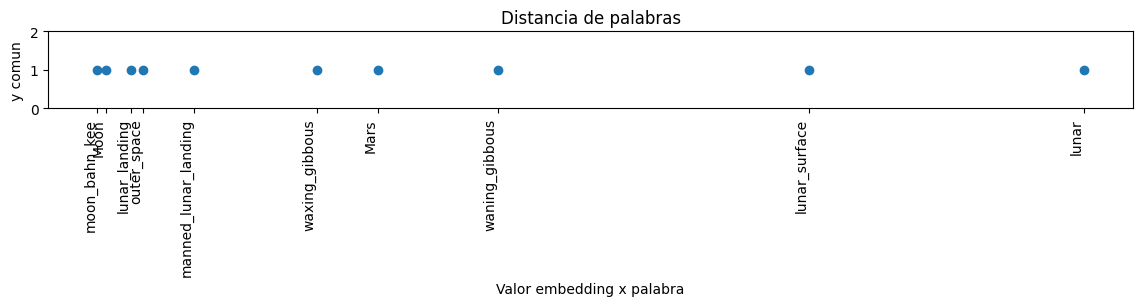

In [29]:
## En este ejemplo graficaremos en una dimensión
## las distancias vectorial de un grupo de palabras.

## usaremos el resultado de p3
## es una lista con suub listas de 3 elementos

## Mostrar distancia de las palabras similares vistas arriba
## sólo en un eje (x) como ejemplo para ver distancias
x, y, p = [], [], [] ## listas para guardar valores de las sub listas
n = 1 ## para tener una altura común

## guardaremos p3 en pejemplo
pejemplo = p3 ## asi se puede cambiar p3 por p2 o p1 para ver otros casos

## guardar valores en las listas x, y, p
for i in range( len( p3 ) ):
    #y.append( p2[i][0] )
    y.append( n )
    x.append( pejemplo[i][1] )
    p.append( pejemplo[i][0] )

## graficar
fig, ax = plt.subplots(figsize=(14, 1))
ax.scatter(x, y)
ax.set_ylim(0, 2)
ax.set_xlabel("Valor embedding x palabra")
ax.set_ylabel("y comun")
ax.set_xticks(x)
ax.set_xticklabels(p, rotation=90, ha='right')
plt.title("Distancia de palabras")

# Display the plot
plt.show()

### A2- Crear un embedding.

AHora reconoceremos el proceso para calcular y transformar texto a embeddings.
Se usará un modelo obtenido desde Hugging Face (Se puede usar openai u otro).
HuggingFace es un respositorio de miles de modelos para ML, DL y LLM.
Pueden verlo acá: https://huggingface.co/


In [30]:
## Para crear embeddings
## Usaremos el modelo sentence-transformers
## Se puede instalar directamente desde Hugging Face usando pip:

!pip install sentence-transformers


In [31]:
## Para calcular embeddings se usa sentence-transformers
## Este ya es un modelo del famoso Transformer (2017)
## importar el modelo instalado

## - – - - – - I M P O R T A N T E - – - - – - - – - ##
## se demora un poco, 1-2 mins.
from sentence_transformers import SentenceTransformer


In [32]:
## Crear una instancia del modelo

## - – - - – - I M P O R T A N T E - – - - – - - – - ##

## se demora un poco, 2-4 mins, pues hace muchos calculos
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [35]:
## Convertir este texto a embeding
emb1 = model.encode("Hola mundo")

## mostrar tamaño del embedding
## todos los embeddings de este modelo tienenel mismo tamaño
print("–TAMAÑO:", emb1.shape)

## muestra los valore del embedding
## el resultado es una lista laaarga de 768 valores
print("–VALORES DEL EMBEDDING:\n", emb1)


–TAMAÑO: (768,)
–VALORES DEL EMBEDDING:
 [ 1.76742412e-02  1.25785917e-01 -1.10590998e-02  8.07093456e-02
  2.19953150e-01  6.60994602e-03 -1.46027040e-02  3.07636000e-02
  6.89361393e-02  2.32642163e-02  5.49177192e-02 -8.51896554e-02
 -5.23980334e-02 -3.60355079e-02  2.28620499e-01 -2.54882693e-01
  1.25053465e-01 -6.04239926e-02 -2.73311496e-01 -4.15842682e-02
  1.15275964e-01 -3.05613726e-02  1.12574168e-01 -9.22447816e-02
  4.08077985e-02  1.07518479e-01 -8.22311863e-02  1.24371707e-01
  6.01274334e-02  7.04638660e-02  1.23964384e-01  1.14022978e-02
  7.12504387e-02 -7.73432432e-03  1.13680691e-01 -8.08565319e-02
  7.96618015e-02 -1.69565920e-02 -1.37967527e-01 -1.77947357e-02
  1.12821504e-01 -9.75775272e-02 -1.08611584e-01  1.07095450e-01
 -1.71698406e-01 -7.62376264e-02 -5.71165979e-02 -1.04472212e-01
  5.31471847e-03  1.16451129e-01  7.42642209e-02  3.84854436e-01
  7.06793964e-02  1.00253962e-01  1.59230590e-01 -6.28340021e-02
  8.33500326e-02 -6.45243824e-02  2.79638395e-02 

In [36]:
## Y ese es un embedding, una representaicon de los numeros,
## pueden probar realizando un embedding de alguna palabra, como su nombre

## Convertir nombre a embeding
nom1 = model.encode("Ricardo")

## todos los embeddings de este modelo tienenel mismo tamaño
print("–TAMAÑO:", nom1.shape)

## el resultado es una lista laaarga de 768 valores
print("–VALORES DEL EMBEDDING:\n", nom1)


–TAMAÑO: (768,)
–VALORES DEL EMBEDDING:
 [ 3.62300687e-02 -5.30121811e-02 -1.60480663e-02  8.66168961e-02
  1.85145378e-01 -1.40737221e-01  8.24171677e-02  1.03687733e-01
  7.26672187e-02  5.61585464e-02  4.32700627e-02  2.80520946e-01
  1.18134832e-02 -1.70295715e-01  2.27181111e-02 -1.45959571e-01
 -3.09019443e-02  8.58306065e-02  5.83063178e-02  2.23330650e-02
 -6.19222112e-02  2.24342048e-02  1.31356671e-01  1.42740197e-02
 -8.61029625e-02  8.46846029e-02  8.52662623e-02 -2.40651239e-02
  4.11535539e-02  2.48214528e-02  1.22943319e-01  6.90521449e-02
 -1.02500655e-01  7.28683472e-02  9.62115824e-02  9.08518434e-02
 -4.29536514e-02 -2.73488611e-02  3.44220400e-02 -2.41645277e-02
  1.80722788e-01  1.03872783e-01 -9.39026251e-02  5.57454042e-02
 -1.98968425e-01  1.73911452e-01  6.04622327e-02 -2.75346875e-01
 -4.01173197e-02 -1.14221245e-01 -2.91453302e-02  5.60900837e-04
  5.11087663e-02 -1.30140379e-01  4.15897250e-01 -2.12083876e-01
 -4.91093583e-02  5.83179109e-02  2.16777280e-01 